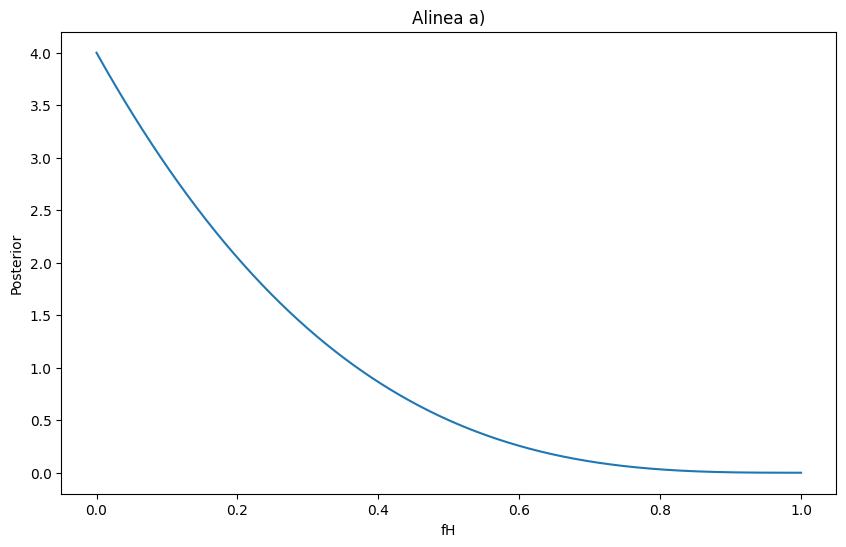

Probabilidade de obter H no próximo lançamento (alínea a): 0.2


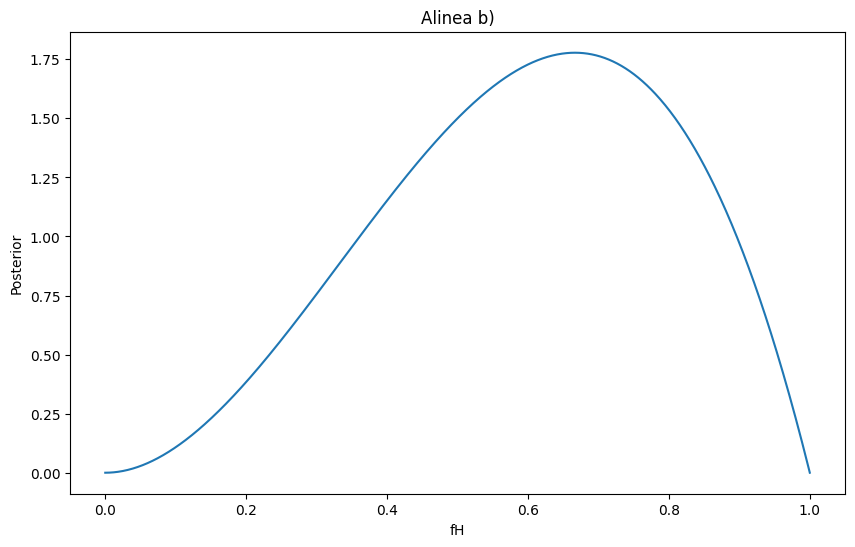

Probabilidade de obter H no próximo lançamento (alínea b): 0.6


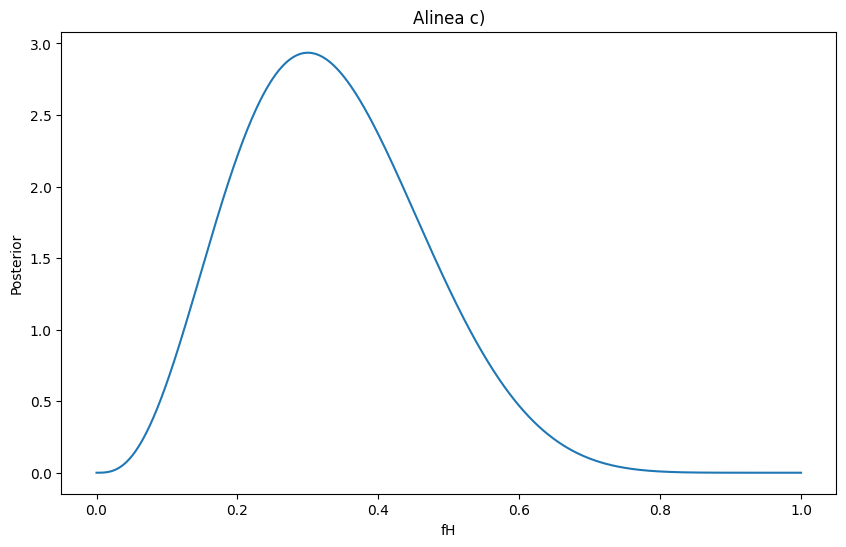

Probabilidade de obter H no próximo lançamento (alínea c): 0.3333333333333333


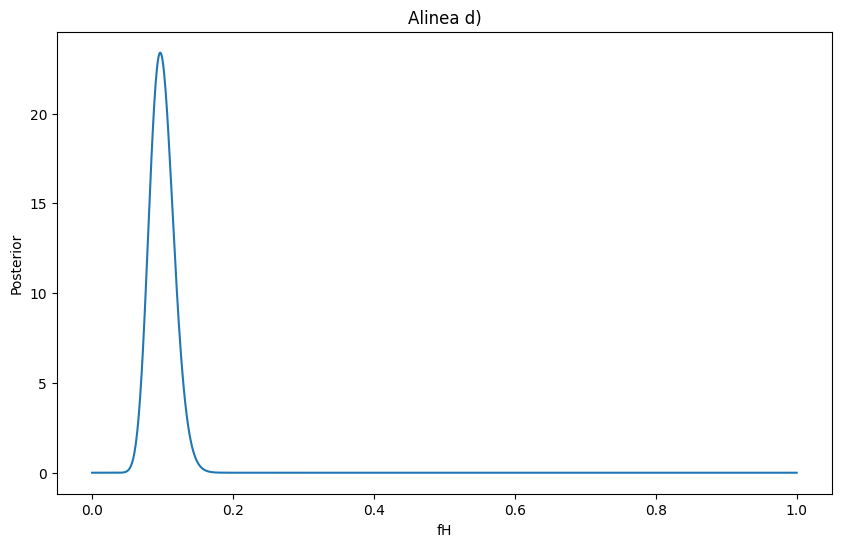

Probabilidade de obter H no próximo lançamento (alínea d): 0.09933774834437085


In [10]:
import cv2 
import numpy as np
import matplotlib.pyplot as plt
from math import factorial

def posterior(f, nH, N):
    C = factorial(N+1) / (factorial(nH) * factorial(N-nH))
    return C * (f**nH) * ((1 - f)**(N-nH))

def prob_proximo(nH, N):
    return (nH + 1) / (N + 2)

f = np.linspace(0, 1, 1000)

# Alinea a)

Na = 3
nHa = 0
posterior_a = posterior(f, nHa, Na)
plt.figure(figsize=(10, 6))
plt.plot(f, posterior_a)
plt.xlabel("fH")
plt.ylabel("Posterior")
plt.title("Alinea a)")
plt.show()
print("Probabilidade de obter H no próximo lançamento (alínea a):", prob_proximo(nHa, Na))

#alinea b)

plt.figure(figsize=(10, 6))
Nb = 3
nHb = 2
posterior_b = posterior(f, nHb, Nb)
plt.plot(f, posterior_b)
plt.xlabel("fH")
plt.ylabel("Posterior")
plt.title("Alinea b)")
plt.show()
print("Probabilidade de obter H no próximo lançamento (alínea b):", prob_proximo(nHb, Nb))

#alinea c)
plt.figure(figsize=(10, 6))
Nc = 10
nHc = 3
posterior_c = posterior(f, nHc, Nc)
plt.plot(f, posterior_c)
plt.xlabel("fH")
plt.ylabel("Posterior")
plt.title("Alinea c)")
plt.show()
print("Probabilidade de obter H no próximo lançamento (alínea c):", prob_proximo(nHc, Nc))

#alinea d)
plt.figure(figsize=(10, 6))
Nd = 300
nHd = 29
posterior_d = posterior(f, nHd, Nd)
plt.plot(f, posterior_d)
plt.xlabel("fH")
plt.ylabel("Posterior")
plt.title("Alinea d)")
plt.show()
print("Probabilidade de obter H no próximo lançamento (alínea d):", prob_proximo(nHd, Nd))

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#P(A) = 0.4, P(B) = 0.35, P(C) = 0.25

P_algoritmo = np.array([0.4, 0.35, 0.25])

P_NC_dado_algoritmo = np.array([
    [0.05, 0.10, 0.20],
    [0.15, 0.20, 0.25],
    [0.40, 0.40, 0.30],
    [0.30, 0.20, 0.15],
    [0.10, 0.10, 0.10]
])

#alinea a)
print("alinea a")

P_conj = P_NC_dado_algoritmo * P_algoritmo

Marginal = np.sum(P_conj, axis=1)

print("P conjunta:\n", P_conj)
print("P marginal:\n", Marginal)

def classifica_algoritmo(NC):
    #selecionar a linha correspondente ao NC
    verosimilhanca = P_NC_dado_algoritmo[NC]
    #aplicar Bayes
    posterior = verosimilhanca * P_algoritmo
    #normalizar
    posterior = posterior / np.sum(posterior)
    return posterior

#alinea b)
print("alinea b")

posterior = classifica_algoritmo(3)

print("Posterior [A, B, C] para NC=3:", posterior)

algoritmos = ["A", "B", "C"]
melhor = algoritmos[np.argmax(posterior)] #utilizei np.argmax para encontrar o índice do algoritmo com maior posterior

print("Melhor algoritmo para NC=3:", melhor)

#alinea c)
print("alinea c")

ml_nc = np.argmax(P_NC_dado_algoritmo, axis=0) #encontra o índice do algoritmo com maior verosimilhança para cada NC

for i, alg in enumerate(algoritmos):
    print(f"Melhor NC para o algoritmo {alg}: NC mais provavel = {ml_nc[i]}")

P_Posterior = P_conj / np.sum(P_conj, axis=1, keepdims=True) #normaliza a matriz conjunta para obter a posterior

map_alg = np.argmax(P_Posterior, axis=1) #encontra o índice do algoritmo com maior posterior para cada NC

for nc in range(5):
    print(f"Melhor algoritmo para NC={nc}: {algoritmos[map_alg[nc]]}")


alinea a
P conjunta:
 [[0.02   0.035  0.05  ]
 [0.06   0.07   0.0625]
 [0.16   0.14   0.075 ]
 [0.12   0.07   0.0375]
 [0.04   0.035  0.025 ]]
P marginal:
 [0.105  0.1925 0.375  0.2275 0.1   ]
alinea b
Posterior [A, B, C] para NC=3: [0.52747253 0.30769231 0.16483516]
Melhor algoritmo para NC=3: A
alinea c
Melhor NC para o algoritmo A: NC mais provavel = 2
Melhor NC para o algoritmo B: NC mais provavel = 2
Melhor NC para o algoritmo C: NC mais provavel = 2
Melhor algoritmo para NC=0: C
Melhor algoritmo para NC=1: B
Melhor algoritmo para NC=2: A
Melhor algoritmo para NC=3: A
Melhor algoritmo para NC=4: A
